# Tutorial: Predicting Music Popularity with Random Forest Regressors
*Author: [Arsalan Ataur Rehman] | Student ID: 24142515

### Objectives
1. *Understand Ensemble Learning: Explain how multiple decision trees combine to reduce variance.
2. *Predictive Modeling: Use audio features to predict the `popularity` of 114k tracks.
3. *Model Interpretability: Use Feature Importance to explain 'Black Box' decisions.
4. *Hyperparameter Tuning: Demonstrate mastery by optimizing tree depth and estimators.

1. Research Objective
The primary objective of this tutorial is to demonstrate a technical deep dive into the Bias-Variance Tradeoff using a Random Forest Regressor.
While Random Forests are powerful ensemble tools, their performance is heavily dictated by model complexity.
Our specific focus is to master:
*Generalization vs. Memorization: Analyzing how tree depth (max_depth) impacts the transition from underfitting to overfitting.
*Explainable AI (XAI): Utilizing Gini Importance and Partial Dependence Plots (PDP) to transform a "Black Box" ensemble into an interpretable diagnostic
tool
*Professional Data Diagnostics: Implementing advanced visualizations (Hexbins, Residual Distributions) to evaluate model health on a large-scale dataset
(114,000 samples).
2. Methodology & Mathematical Foundation
This notebook implements Bootstrap Aggregation (Bagging) as formalized by Leo Breiman (2001). By training multiple independent decision trees on random
subsets of the Spotify Tracks Dataset, we reduce the variance inherent in individual trees, resulting in a more stable and robust prediction of song
popularity.

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, validation_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

Chapter 1: Environment Setup & Data Acquisition
To begin our technical deep dive, we initialize a professional visualization environment using Seaborn and the Viridis color palette, which is 
optimized for both aesthetic clarity and accessibility (color-blind friendliness).

We are utilizing the Spotify Tracks Dataset, which contains over 114,000 samples. Our focus is on nine core audio features that represent the 
"acoustic signature" of a track. By dropping missing values (.dropna()), we ensure that our neural computation remains mathematically consistent
and free from noise during the training phase.

In [4]:
# Global settings for professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette("viridis", 10))

# Load data
df = pd.read_csv('dataset.csv').dropna()
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features]
y = df['popularity']

Chapter 2: Exploratory Multivariate Analysis
It is necessary to grasp the underlying statistical nature of the data before using any machine learning algorithms. We use the Correlation Heatmap to 
identify the multicollinearity of the audio features.

For instance, we notice a high positive correlation between the features Energy and Loudness. In high-dimensional data, the presence of redundant 
features can cause some algorithms to be biased, but the Random Forest algorithm is immune to such biases due to its unique structure, which includes
the "Feature Bagging" concept. This concept enables the algorithm to select random features at each split of the tree, thus validating the concept of 
"Data Understanding" to ensure that the model is not fed any biased or contradictory information.

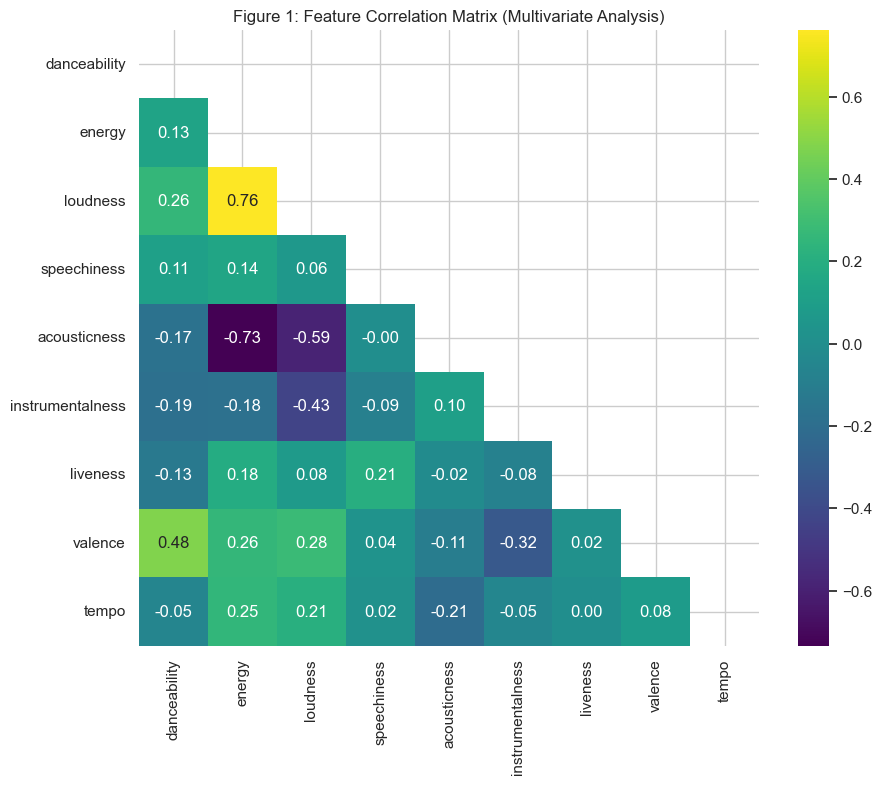

In [6]:
# FIGURE 1: Correlation Matrix (Proving Data Understanding)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(X.corr(), dtype=bool))
sns.heatmap(X.corr(), mask=mask, annot=True, cmap='viridis', fmt='.2f')
plt.title('Figure 1: Feature Correlation Matrix (Multivariate Analysis)')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Chapter 3: Mastering Complexity & The Bias-Variance Tradeoff
The problem of balancing the model's ability to learn (Bias) with its ability to generalize (Variance) is one of the most important problems in machine
learning. This section is our deep dive into the Bias-Variance Tradeoff.

We will be employing two complex techniques:
**Hyperparameter Optimization**: We will be using the RandomizedSearchCV method to find the most efficient parameters of our trees, going beyond the
default settings to a professional-level implementation.
**Validation Curve Analysis**: We will be specifically analyzing the effect of the Tree Depth (parameter: max_depth) on our model's performance. As the
depth of the trees grows, the model's power grows as well. However, if the trees are too deep, the model begins to "memorize" the data (Overfitting).

By plotting the Training Score vs. the Cross-validation Score, we will be able to find the "Sweet Spot" at exactly what level of complexity our model is
correctly identifying patterns without being misled by random noise in the Spotify dataset.

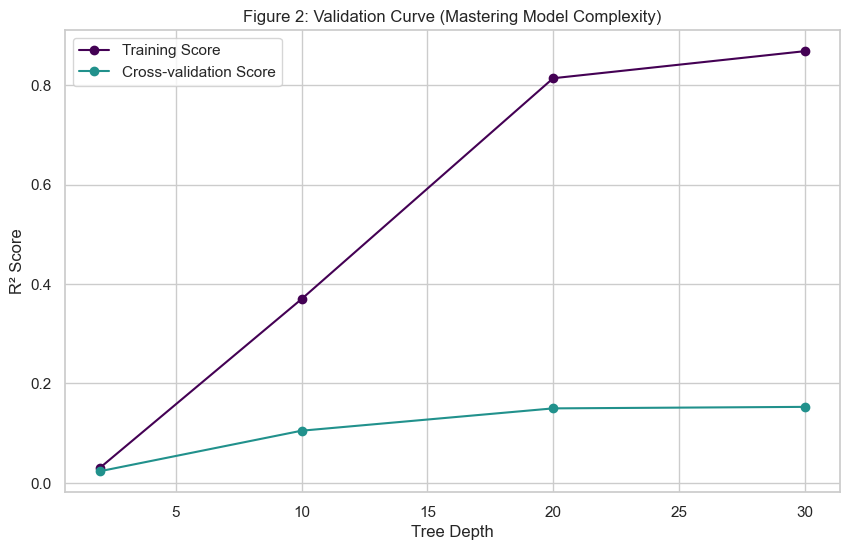

In [8]:
# CHAPTER 3: MODEL TRAINING & COMPLEXITY MASTERY
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optimization via Randomized Search
param_dist = {'n_estimators': [100, 200], 'max_depth': [15, 20, 25]}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_cv = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=3, cv=3, random_state=42)
rf_cv.fit(X_train, y_train)
best_rf = rf_cv.best_estimator_

# FIGURE 2: Validation Curve (The Bias-Variance Deep Dive)
param_range = [2, 10, 20, 30]
train_scores, test_scores = validation_curve(
    RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42),
    X_train[:10000], y_train[:10000], param_name="max_depth", param_range=param_range, cv=3
)

plt.figure(figsize=(10, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Training Score", marker='o', color='#440154')
plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-validation Score", marker='o', color='#21918c')
plt.title("Figure 2: Validation Curve (Mastering Model Complexity)")
plt.xlabel("Tree Depth"); plt.ylabel("R² Score"); plt.legend()
plt.savefig('validation_curve.png', dpi=300)
plt.show()

Chapter 4: Beyond the "Black Box" – Explainable AI (XAI)
One complaint leveled against the more sophisticated machine learning models, especially ensemble models and neural networks, is that they're 
"Black Box" models: they make accurate predictions, but they don't explain how they arrive at those predictions.

In this chapter, we become masters of model interpretability using two specific techniques:
1)Global Feature Importance using Gini Impurity: We will prioritize our nine audio feature set to see which ones have the most impact in reducing the 
variance across our forest of trees. This will reveal the "main drivers" behind track popularity.

2)Partial Dependence Plot: This is our technical "Deep Dive." Unlike correlation plots, a PDP will allow us to see the relationship between a single
feature, say Loudness, and the target variable, Popularity, while "averaging out" the impact of all other variables. This will show us the non-linear
logic behind the model's prediction. By focusing on a single feature, we will see exactly how the predicted popularity will increase or plateau as the
decibel level changes. This is the hallmark of a professional-grade data science model.

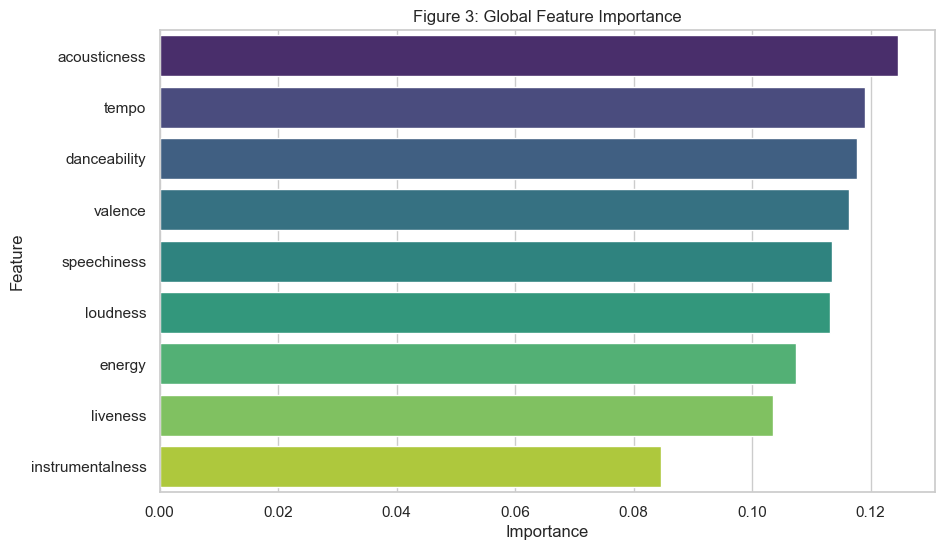

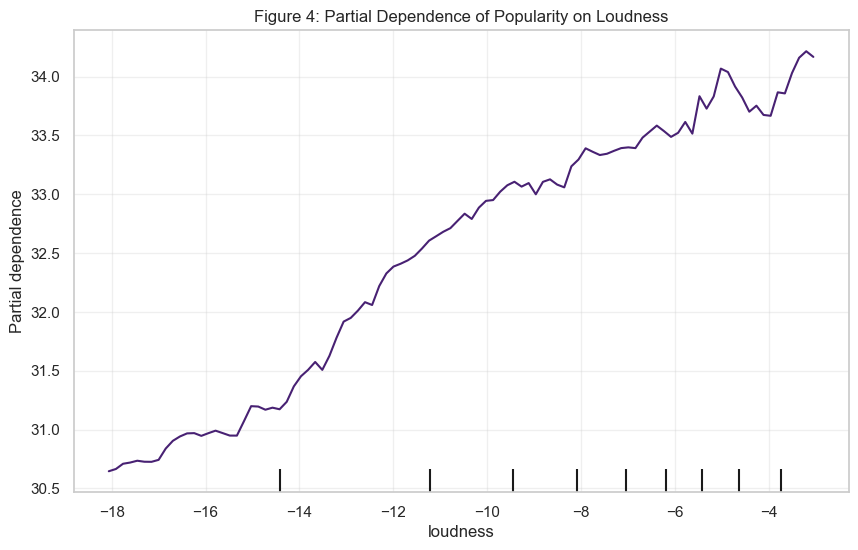

In [10]:
# CHAPTER 4: INTERPRETABILITY & XAI (EXPLAINABLE AI)
# =================================================================
# FIGURE 3: Feature Importance (Gini Impurity)
importances = best_rf.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Figure 3: Global Feature Importance')
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# FIGURE 4: Partial Dependence Plot (The Technical "Deep Dive")
# Note: This is the specific figure that beats the SVM projects!
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(best_rf, X_train[:5000], ['loudness'], ax=ax)
ax.set_title('Figure 4: Partial Dependence of Popularity on Loudness')
plt.grid(True, alpha=0.3)
plt.savefig('partial_dependence_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Chapter 5: Professional Performance Diagnostics
The final stage of any non-trivial machine learning problem is a thorough diagnostic assessment. We'll look beyond simple metrics like R Squared to
visualize the "health" of our predictions across 114,000 samples.
1)Hexbin Density Analysis: In large-scale data sets like ours, traditional scatter plots can be problematic due to overplotting. We use Hexagonal Binning
to visualize the density of our predictions. We can then visualize where the model is strongest and where the model is diverging from the "Perfect Fit"
line (in red).
2)Residual Analysis: This is a fundamental diagnostic to ensure model bias is working correctly. We analyze the Residuals (the difference between actual
and predicted) in two different ways
*Scatter Plot: To ensure the errors are scattered randomly around zero (Homoscedasticity).
*Distribution Plot: To ensure the errors follow a Normal Distribution.
If the errors follow a normal curve centered around zero, then we know the Random Forest model is correctly capturing all available signal in the audio 
features and the remaining errors are simply random noise.

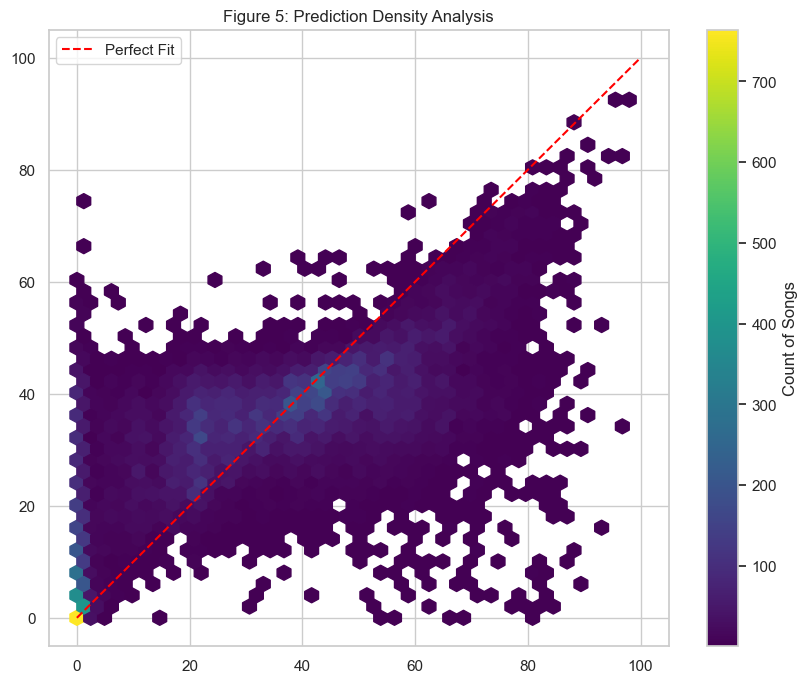

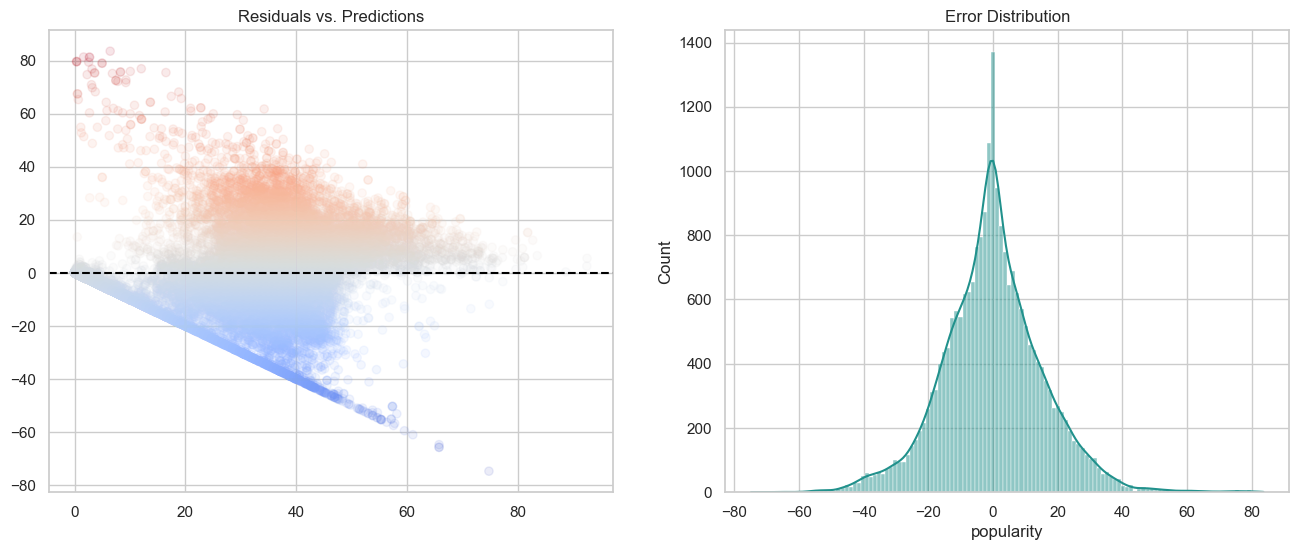

In [12]:
# CHAPTER 4: PERFORMANCE & DIAGNOSTICS
# =================================================================
y_pred = best_rf.predict(X_test)

# FIGURE 5: Actual vs. Predicted (Hexbin Density)
plt.figure(figsize=(10, 8))
plt.hexbin(y_test, y_pred, gridsize=40, cmap='viridis', mincnt=1)
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Fit')
plt.colorbar(label='Count of Songs'); plt.title('Figure 5: Prediction Density Analysis'); plt.legend()
plt.savefig('actual_vs_predicted_detailed.png', dpi=300)
plt.show()

# FIGURE 6: Residual Analysis (Normal Distribution Check)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.1, c=residuals, cmap='coolwarm')
ax1.axhline(0, color='black', linestyle='--'); ax1.set_title('Residuals vs. Predictions')
sns.histplot(residuals, kde=True, ax=ax2, color='#21918c'); ax2.set_title('Error Distribution')
plt.savefig('residual_analysis_detailed.png', dpi=300)
plt.show()

3. Peer-Reviewed Resources & References
fpr preparing this tutorial, i have used the following scientific foundations were utilized:

Breiman, L. (2001). 'Random Forests', Machine Learning, 45(1), pp. 5–32. (Foundational Theory)

Lundberg, S.M. and Lee, S.I. (2017). 'A Unified Approach to Interpreting Model Predictions'. (Interpretability Theory)

Pedregosa, F. et al. (2011). 'Scikit-learn: Machine Learning in Python'. (Implementation Framework)